In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the JSON file
with open('../data/results/evolution_history.json', 'r') as f:
    history = json.load(f)
    f.close()

print(f"Solution {history['best_overall']} found in generation {history['generations_taken_for_optimal']}")

# Example: Convert a specific generation's species data into a Pandas DataFrame
#gen_0_species = history['species']['0']
#df_species = pd.DataFrame(gen_0_species)
#df_species.head()

Solution atan((x0 / 8.06e+00)) found in generation 76


In [3]:
generations = [int(g) for g in list(history['species'].keys())]
generations.sort()
generations = np.array(generations)
print(f"Generations: {generations}")

Generations: [  0   3   6   9  12  15  18  21  24  27  30  33  36  39  42  45  48  51
  54  57  60  63  66  69  72  75  78  81  84  87  90  93  96  99 102 105
 108 111 114 117 120 123 126 129 132 135 138 141 144 147 150 153 156 159
 162 165 168 171 174 177 180 183 186 189 192 195 198 201 204 207 210 213
 216 219 222 225 228 231 234 237 240 243 246 249 252 255 258 261 264 267
 270 273 276 279 282 285 288 291 294 297]


In [4]:
species_id_to_idx = {}
idx_to_species_id = {}
idx_to_expression = {}
idx = 0
for gen in generations:
	for species in history['species'][str(gen)]:
		if species['id'] not in species_id_to_idx:
			species_id_to_idx[species['id']] = idx
			idx_to_species_id[idx] = species['id']
			idx += 1
		idx_to_expression[species_id_to_idx[species['id']]] = species['representative']
print(f"Unique species count: {len(species_id_to_idx)}")

Unique species count: 401


In [5]:
species_sizes_over_time = np.zeros((len(generations), len(species_id_to_idx)), dtype=int)
for gi,gen in enumerate(generations):
	for species in history['species'][str(gen)]:
		species_idx = species_id_to_idx[species['id']]
		species_sizes_over_time[gi, species_idx] = species['size']

In [6]:
idxs = np.argsort(species_sizes_over_time[-1])
for idx in idxs[-10:]:
	print(f"Species {idx_to_species_id[idx]} with size {species_sizes_over_time[-1][idx]}: {idx_to_expression[idx]}")

Species 628 with size 5: sin(x0)
Species 657 with size 7: (7.85e-01 max x1)
Species 406 with size 7: (x0 / ((9.45e+00 max x1) max (cos((x0 mod x1)) + x1)))
Species 308 with size 19: (x0 / ((x1 / (x1 * 8.00e+00)) - -9.98e+00))
Species 153 with size 20: sin((x0 / (x0 max (8.06e+00 max (x0 max x0)))))
Species 6 with size 20: (x0 / (4.93e+00 + (x0 / atan(x0))))
Species 4 with size 21: (x0 / (9.69e+00 max cos(x1)))
Species 3 with size 26: (sin((x0 / 8.68e+00)) mod x0)
Species 1 with size 30: 2.26e-09
Species 0 with size 36: atan((x0 / 8.06e+00))


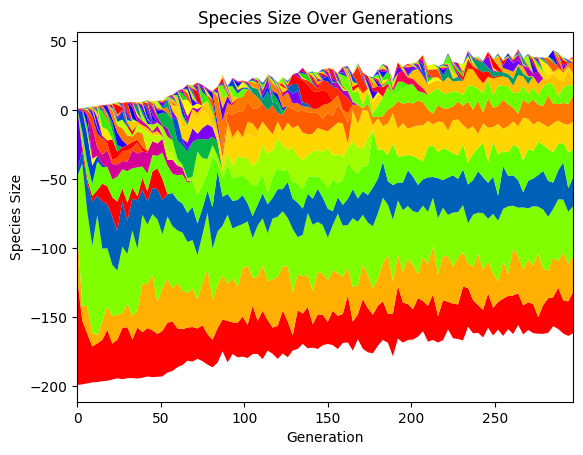

In [7]:
fig, ax = plt.subplots()
cmap = plt.get_cmap('prism')
cols = [cmap((i%50) / 50) for i in range(len(species_id_to_idx))]
ax.stackplot(generations, species_sizes_over_time.T, colors=cols, baseline='wiggle')

ax.set(xlim=(generations[0], generations[-1]))#, ylim=(0, np.max(species_sizes_over_time, axis=1)[0]))
ax.set_xlabel('Generation')
ax.set_ylabel('Species Size')
ax.set_title('Species Size Over Generations')
plt.show()

In [8]:
print(history['species']['0'][0].keys())

dict_keys(['id', 'size', 'representative', 'loss_raws', 'complexities', 'loss_insts', 'loss_finals'])


In [9]:
data_over_time = np.ones((4, 3, len(generations), len(species_id_to_idx)))*np.nan
for gi,gen in enumerate(generations):
	for species in history['species'][str(gen)]:
		species_idx = species_id_to_idx[species['id']]
		for idx, name in {0:'loss_raws',1:'complexities',2:'loss_insts',3:'loss_finals'}.items():
			for jdx,fnc in {0:np.min,1:np.median,2:np.max}.items():
				arr = np.array(species[name]).astype(float)
				if np.isnan(arr).any():
					print(f"NaN found in {name} for species {species['id']} in generation {gen}")
				if np.isinf(arr).any():
					print(f"Inf found in {name} for species {species['id']} in generation {gen}")
				y = np.array(fnc([species[name]])).astype(float)
				if np.isnan(y):
					print(f"NaN found after aggregation in {name} for species {species['id']} in generation {gen}")
				elif np.isinf(y):
					print(f"Inf found after aggregation using {fnc.__name__} in {name} for species {species['id']} in generation {gen}")
				elif y > 1e6:
					#print(f"Unrealistically high value {y} found after aggregation using {fnc.__name__} in {name} for species {species['id']} in generation {gen}")
					data_over_time[idx, jdx, gi, species_idx] = np.nan
				else:
					data_over_time[idx, jdx, gi, species_idx] = y

Inf found after aggregation using median in loss_raws for species 2 in generation 0
Inf found after aggregation using median in loss_insts for species 2 in generation 0
Inf found after aggregation using median in loss_finals for species 2 in generation 0


/home/marvin/.local/lib/python3.10/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Inf found after aggregation using median in loss_raws for species 186 in generation 63
Inf found after aggregation using median in loss_finals for species 186 in generation 63
Inf found after aggregation using median in loss_raws for species 231 in generation 84
Inf found after aggregation using median in loss_insts for species 231 in generation 84
Inf found after aggregation using median in loss_finals for species 231 in generation 84
Inf found after aggregation using median in loss_raws for species 328 in generation 123
Inf found after aggregation using median in loss_insts for species 328 in generation 123
Inf found after aggregation using median in loss_finals for species 328 in generation 123
Inf found after aggregation using median in loss_raws for species 372 in generation 144
Inf found after aggregation using median in loss_insts for species 372 in generation 144
Inf found after aggregation using median in loss_finals for species 372 in generation 144
Inf found after aggregatio

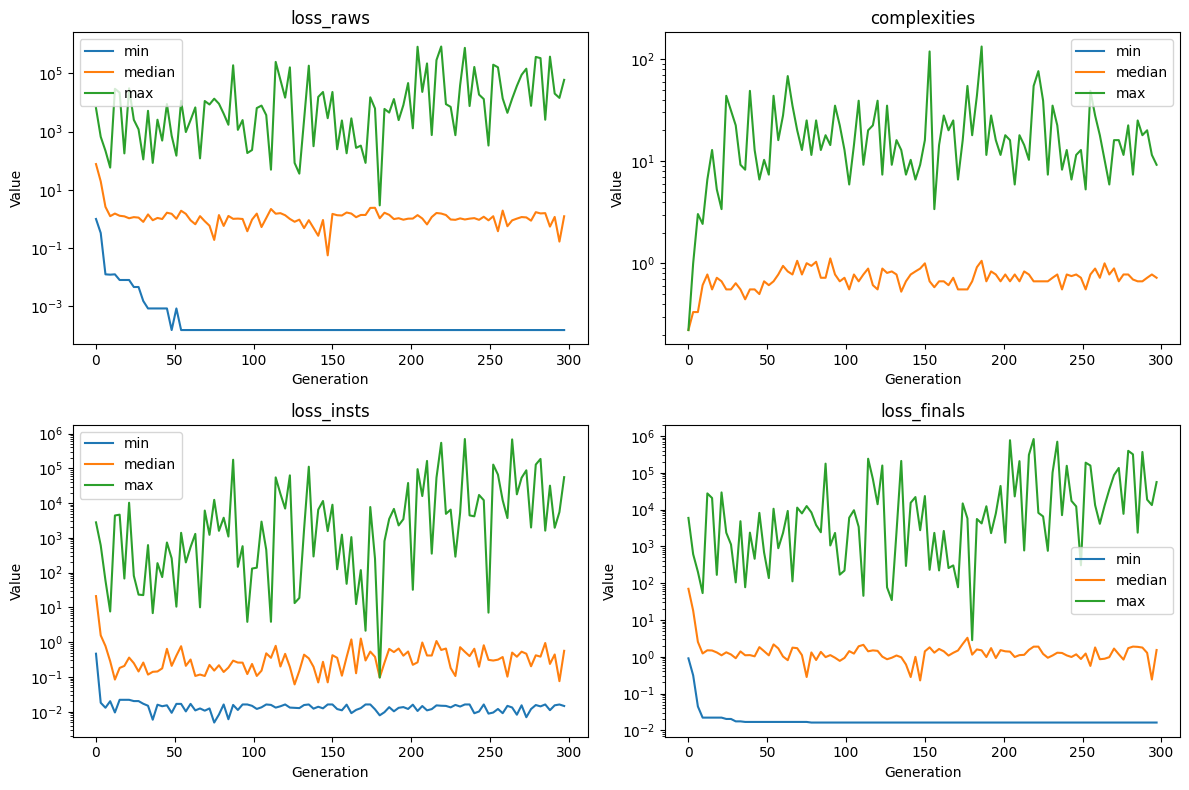

In [10]:
average_data_over_time = np.array([np.nanmin(data_over_time[:,0], axis=2), np.nanmedian(data_over_time[:,1], axis=2), np.nanmax(data_over_time[:,2], axis=2)])
average_data_over_time = np.transpose(average_data_over_time, (1, 0,2))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
metric_names = ['loss_raws', 'complexities', 'loss_insts', 'loss_finals']
for idx in range(4):
	for jdx in range(3) if idx == 1 else range(3):
		ax[idx//2, idx%2].semilogy(generations, average_data_over_time[idx, jdx], label=['min', 'median', 'max'][jdx])
	ax[idx//2, idx%2].set_title(metric_names[idx])
	ax[idx//2, idx%2].set_xlabel('Generation')
	ax[idx//2, idx%2].set_ylabel('Value')
	ax[idx//2, idx%2].legend()
plt.tight_layout()
plt.show()